# Notebook 02 — Hệ thống cơ sở

Notebook này dựng hệ thống truy hồi đầu tiên và **kiểm chứng nó chạy đúng**
trước khi bước vào cải tiến.

Nếu bỏ qua bước kiểm chứng, mọi thí nghiệm sau sẽ đo trên một nền sai mà không
có cách nào phát hiện.

| Mục | Nội dung |
| --- | --- |
| 1 | Cửa ải: mã của ta có giống hệt mã ban tổ chức không |
| 2 | Chạy BM25 trên đủ 13 nhóm |
| 3 | So với điểm chuẩn chính thức |
| 4 | Giải thích khoảng cách |
| 5 | Chốt mốc cơ sở cho các bước sau |

## Hai baseline khác nhau trong bộ công cụ

Điều này cần làm rõ trước, vì nó quyết định cách đọc mọi con số phía dưới.

`RETECO/starter_kit/` chứa **hai** chương trình baseline khác nhau:

| File | Cách tách từ | Phụ thuộc | Ghi chú của ban tổ chức |
| --- | --- | --- | --- |
| `official_baseline.py` | Lucene analyzer (qua pyserini) | Java JDK, pyserini, gensim | *"Reproduces the published RETECO baseline numbers"* |
| `bm25_baseline.py` | `[A-Za-z0-9]+` viết thường | không có | *"Zero-install starting point; **approximate**"* |

Con số **0,0879** trong `BASELINE_RESULTS.md` đến từ file **thứ nhất**.

Bản thuần Python được ban tổ chức ghi rõ là **xấp xỉ** — nó sẽ *không* cho ra
0,0879. Notebook này dùng bản thuần Python (không cần cài Java), nên cửa ải
kiểm chứng phải đặt đúng chỗ:

> **Cửa ải:** mã của ta phải cho ra kết quả **giống hệt** `bm25.py` của ban tổ
> chức khi dùng cùng cách tách từ.

Còn khoảng cách tới 0,0879 là do **cách tách từ**, và đó chính là thí nghiệm
đầu tiên ở mục 4.

## 0. Chuẩn bị

In [1]:
import sys
import json
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# src/reteco.py holds everything shared between notebooks
sys.path.insert(0, str(Path("..") / "src"))
import reteco as R

DATA = Path(r"D:\RETECO-project\reteco_data\track1_tempo")
CACHE = Path("results")
CACHE.mkdir(exist_ok=True)

assert DATA.is_dir(), f"Dataset not found at {DATA}"
domains = R.list_domains(DATA)
print(f"{len(domains)} domains: {', '.join(domains)}")

13 domains: bitcoin, cardano, economics, genealogy, history, hsm, iota, law, monero, politics, quant, travel, workplace


In [2]:
# --- Shared chart style -------------------------------------------------
# One palette and one set of helpers for every figure, so the notebook reads
# as a single document rather than a pile of unrelated plots.
# Palette is colour-vision-deficiency safe; values are always labelled so the
# chart never relies on colour alone.
BLUE, ORANGE, TEAL, AMBER, PINK, VIOLET = (
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7")
SURFACE, INK, INK_SOFT, INK_MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS = "#e1e0d9", "#c3c2b7"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS,
    "axes.labelcolor": INK_SOFT,
    "axes.labelsize": 9.5,
    "text.color": INK,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "font.size": 10,
    "figure.dpi": 120,
    "axes.linewidth": 0.9,
})


def finish(ax, title, subtitle=None, xlabel=None, ylabel=None,
           grid_axis="y", note=None):
    """Apply the shared layout: title block, recessive grid, minimal frame.

    The title carries the claim; the subtitle carries the qualifier. Keeping
    them apart stops titles from turning into sentences.
    """
    if subtitle:
        # Subtitle sits just above the axes; the title is offset further up in
        # POINTS, not axes fractions, so the gap holds at any figure size.
        ax.set_title(subtitle, loc="left", pad=8, fontsize=9.5, color=INK_MUTED)
        ax.annotate(title, xy=(0, 1), xycoords="axes fraction",
                    xytext=(0, 24), textcoords="offset points",
                    ha="left", va="bottom", fontsize=12.5,
                    fontweight="bold", color=INK, annotation_clip=False)
    else:
        ax.set_title(title, loc="left", pad=12, fontsize=12.5,
                     fontweight="bold", color=INK)

    ax.set_xlabel(xlabel or "")
    ax.set_ylabel(ylabel or "")

    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    # The gridline already marks the scale; the spine it runs into is noise.
    ax.spines["left" if grid_axis == "x" else "bottom"].set_color(AXIS)
    if grid_axis == "x":
        ax.spines["bottom"].set_visible(False)
    else:
        ax.spines["left"].set_visible(False)

    if grid_axis:
        ax.grid(axis=grid_axis, color=GRID, linewidth=0.8)
        ax.set_axisbelow(True)
    ax.tick_params(length=0)

    if note:
        ax.text(0, -0.34, note, transform=ax.transAxes, ha="left", va="top",
                fontsize=8.5, color=INK_MUTED)
    return ax


def label_bars(ax, bars, values, fmt="{:,.0f}", horizontal=True, pad=0.015):
    """Direct value labels. Always present, so colour never carries the number."""
    span = max(values) if values else 1
    for bar, value in zip(bars, values):
        if horizontal:
            ax.text(bar.get_width() + span * pad,
                    bar.get_y() + bar.get_height() / 2,
                    fmt.format(value), va="center", ha="left",
                    fontsize=8.5, color=INK_SOFT)
        else:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + span * pad,
                    fmt.format(value), ha="center", va="bottom",
                    fontsize=8.5, color=INK_SOFT)


def legend_below(ax, ncol=2, y=-0.30):
    ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, y),
              ncol=ncol, fontsize=9.5, handlelength=1.1, handleheight=1.1,
              columnspacing=1.8)

## 1. Cửa ải — mã của mình có *liêm* không? :))

`reteco.py` chứa hai bản BM25:

- `BM25` — bản nhanh, dùng ma trận thưa. Đây là bản sẽ dùng thật.
- `reference_bm25_search` — chép nguyên văn thuật toán từ `bm25.py` của ban
  tổ chức, cố tình **không tối ưu**. Nhiệm vụ duy nhất của nó là làm mốc đối chiếu.

Hai bản phải cho ra **thứ hạng giống hệt nhau**. Kiểm tra trên `iota` — nhóm
nhỏ nhất, vì bản gốc chạy rất chậm (nó tính điểm cho *mọi* tài liệu với *mọi*
câu hỏi).

In [3]:
GATE_DOMAIN = "iota"

doc_ids, doc_texts = R.load_corpus(DATA / GATE_DOMAIN / "documents.jsonl")
gate_queries = R.load_queries(DATA / GATE_DOMAIN / "examples_train.jsonl")
print(f"{GATE_DOMAIN}: {len(doc_ids):,} documents, {len(gate_queries)} queries")

t0 = time.time()
index = R.BM25(doc_ids, doc_texts, tokenizer=R.tokenize_simple)
print(f"fast index built in {time.time() - t0:.1f}s\n")

identical = 0
largest_gap = 0.0
for qid, query_text in gate_queries:
    fast = index.search(query_text, top_k=100)
    reference = R.reference_bm25_search(doc_ids, doc_texts, query_text, top_k=100)

    if [d for d, _ in fast] == [d for d, _ in reference]:
        identical += 1
    else:
        print(f"  RANKING MISMATCH on query {qid}")
    largest_gap = max(largest_gap,
                      max(abs(a - b) for (_, a), (_, b) in zip(fast, reference)))

print(f"{identical}/{len(gate_queries)} queries: rankings identical")
print(f"largest score difference: {largest_gap:.2e}")

assert identical == len(gate_queries), "GATE FAILED - do not trust anything below"
print("\nGATE PASSED")

iota: 10,372 documents, 7 queries
fast index built in 8.4s

7/7 queries: rankings identical
largest score difference: 2.27e-13

GATE PASSED


> **Vì sao phải so *thứ hạng*, không phải chỉ so điểm số**
>
> Trong lúc dựng, hai bản từng cho ra điểm khớp nhau tới `1e-13` nhưng **thứ
> hạng vẫn khác**. Nguyên nhân: có **92 tài liệu cùng một điểm** ở đúng chỗ cắt
> top-100 — chúng là các bản sao mà EDA đã phát hiện ở Notebook 01a.
>
> Bản gốc phân định các tài liệu đồng điểm bằng mã tài liệu. Bản nhanh ban đầu
> chọn tuỳ tiện. Nếu chỉ kiểm tra điểm số thì lỗi này lọt qua hoàn toàn.
>
> Đây là ví dụ cụ thể cho thấy vì sao cửa ải phải kiểm tra thứ đúng.

## 2. Chạy BM25 trên đủ 13 nhóm

Mỗi nhóm được xử lý với **hai cách tách từ**:

| Cách | Mô tả |
| --- | --- |
| `simple` | Viết thường, giữ chữ và số — giống `bm25.py` của ban tổ chức |
| `lucene` | Mô phỏng Lucene analyzer: bỏ sở hữu cách, bỏ 33 từ dừng, rút gọn từ về gốc |

Cách thứ hai là để trả lời câu hỏi ở mục 4: khoảng cách tới 0,0879 do đâu mà ra.

Mất khoảng 10–20 phút. Kết quả lưu vào `results/` nên lần sau chạy lại là tức thì.

In [4]:
TOKENIZERS = {
    "simple": R.tokenize_simple,
    "lucene": R.tokenize_lucene,
}

cache_file = CACHE / "baseline.json"

if cache_file.exists():
    saved = json.loads(cache_file.read_text(encoding="utf-8"))
    results = saved["results"]
    print("Loaded from cache. Delete results/baseline.json to rerun.")
else:
    results = {name: {} for name in TOKENIZERS}
    started = time.time()

    for i, domain in enumerate(domains, start=1):
        texts_ids, texts = R.load_corpus(DATA / domain / "documents.jsonl")
        queries = R.load_queries(DATA / domain / "examples_train.jsonl")
        gold = R.load_qrels(DATA / domain / "qrels_train.txt")

        line = f"  [{i:>2}/{len(domains)}] {domain:<12}{len(texts_ids):>9,} docs"
        for name, tokenizer in TOKENIZERS.items():
            t0 = time.time()
            # Built and released one at a time: two indexes for `history`
            # at once is gigabytes of RAM for no reason.
            bm25 = R.BM25(texts_ids, texts, tokenizer=tokenizer)
            run = {qid: [d for d, _ in bm25.search(text, top_k=100)]
                   for qid, text in queries}
            del bm25

            scored = R.evaluate(run, gold)
            results[name][domain] = scored
            line += f"   {name} {scored['ndcg']:.4f} ({time.time() - t0:>4.0f}s)"

        print(line, flush=True)
        del texts_ids, texts

    cache_file.write_text(json.dumps({"results": results}, indent=1),
                          encoding="utf-8")
    print(f"\nTotal: {(time.time() - started) / 60:.1f} min")

for name in TOKENIZERS:
    topics = sum(r["n_topics"] for r in results[name].values())
    print(f"\n{name:<8} macro nDCG@10 = {R.macro(results[name]):.4f}"
          f"   n_topics = {topics}")

Loaded from cache. Delete results/baseline.json to rerun.

simple   macro nDCG@10 = 0.0719   n_topics = 1211

lucene   macro nDCG@10 = 0.0706   n_topics = 1211


`n_topics` được in cùng với điểm, theo đúng nguyên tắc rút ra từ EDA: hai con
số điểm chỉ so sánh được khi số câu hỏi được chấm bằng nhau. Cả hai đều phải
bằng **1.211**.

## 3. So với điểm chuẩn chính thức

In [5]:
# Published BM25 baseline, train split, per domain.
# Source: RETECO/starter_kit/BASELINE_RESULTS.md
OFFICIAL = {
    "bitcoin": 0.0695, "cardano": 0.1349, "economics": 0.0382,
    "genealogy": 0.1003, "history": 0.0691, "hsm": 0.1627,
    "iota": 0.0199, "law": 0.0943, "monero": 0.0278,
    "politics": 0.2792, "quant": 0.0255, "travel": 0.0429,
    "workplace": 0.0777,
}
OFFICIAL_MACRO = 0.0879

order = sorted(domains, key=lambda d: -OFFICIAL[d])

print(f"{'domain':<12}{'official':>10}{'simple':>10}{'lucene':>10}"
      f"{'simple-off':>12}{'lucene-off':>12}")
print("-" * 66)
for d in order:
    s = results["simple"][d]["ndcg"]
    l = results["lucene"][d]["ndcg"]
    print(f"{d:<12}{OFFICIAL[d]:>10.4f}{s:>10.4f}{l:>10.4f}"
          f"{s - OFFICIAL[d]:>+12.4f}{l - OFFICIAL[d]:>+12.4f}")

macro_simple = R.macro(results["simple"])
macro_lucene = R.macro(results["lucene"])
print("-" * 66)
print(f"{'MACRO':<12}{OFFICIAL_MACRO:>10.4f}{macro_simple:>10.4f}{macro_lucene:>10.4f}"
      f"{macro_simple - OFFICIAL_MACRO:>+12.4f}{macro_lucene - OFFICIAL_MACRO:>+12.4f}")

domain        official    simple    lucene  simple-off  lucene-off
------------------------------------------------------------------
politics        0.2792    0.2612    0.2506     -0.0180     -0.0286
hsm             0.1627    0.1980    0.1596     +0.0353     -0.0031
cardano         0.1349    0.0965    0.1227     -0.0384     -0.0122
genealogy       0.1003    0.0545    0.0446     -0.0458     -0.0557
law             0.0943    0.0373    0.0333     -0.0570     -0.0610
workplace       0.0777    0.0599    0.0595     -0.0178     -0.0182
bitcoin         0.0695    0.0343    0.0284     -0.0352     -0.0411
history         0.0691    0.0379    0.0374     -0.0312     -0.0317
travel          0.0429    0.0405    0.0412     -0.0024     -0.0017
economics       0.0382    0.0387    0.0427     +0.0005     +0.0045
monero          0.0278    0.0207    0.0152     -0.0071     -0.0126
quant           0.0255    0.0000    0.0099     -0.0255     -0.0156
iota            0.0199    0.0558    0.0726     +0.0359     +0.

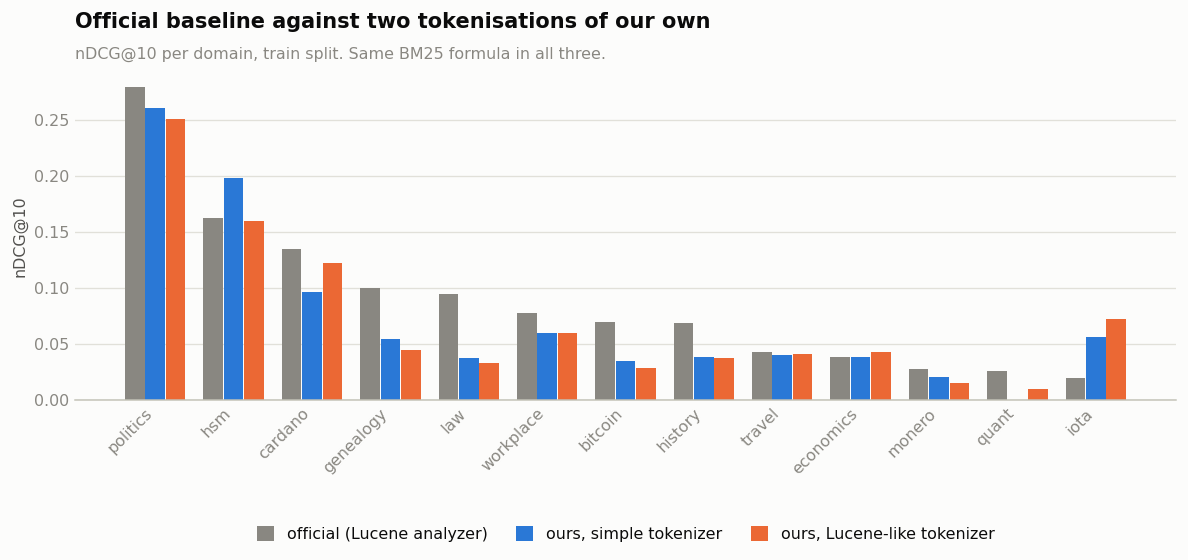

In [6]:
x = np.arange(len(order))

fig, ax = plt.subplots(figsize=(10.0, 5.2))
ax.bar(x - 0.26, [OFFICIAL[d] for d in order], width=0.25,
       color=INK_MUTED, label="official (Lucene analyzer)")
ax.bar(x, [results["simple"][d]["ndcg"] for d in order], width=0.25,
       color=BLUE, label="ours, simple tokenizer")
ax.bar(x + 0.26, [results["lucene"][d]["ndcg"] for d in order], width=0.25,
       color=ORANGE, label="ours, Lucene-like tokenizer")

ax.set_xticks(x)
ax.set_xticklabels(order, rotation=45, ha="right")
finish(ax,
       "Official baseline against two tokenisations of our own",
       subtitle="nDCG@10 per domain, train split. Same BM25 formula in all three.",
       ylabel="nDCG@10")
legend_below(ax, ncol=3, y=-0.34)
plt.tight_layout()
plt.show()

## 4. Khoảng cách tới 0,0879 do đâu?

Ba con số ở trên cho phép tách nguyên nhân.

Cả ba dùng **cùng một công thức BM25** (k1=0,9 — b=0,4 — cùng cách tính idf).
Điểm khác duy nhất giữa chúng là **cách tách từ**.

In [7]:
gap_total = OFFICIAL_MACRO - macro_simple
gap_closed = macro_lucene - macro_simple

print(f"  simple tokenizer          {macro_simple:.4f}")
print(f"  Lucene-like tokenizer     {macro_lucene:.4f}")
print(f"  official (real Lucene)    {OFFICIAL_MACRO:.4f}")
print()
print(f"  gap to close              {gap_total:+.4f}")
share = f"   ({100 * gap_closed / gap_total:.0f}% of the gap)" if gap_total else ""
print(f"  closed by tokenisation    {gap_closed:+.4f}{share}")
print(f"  still unexplained         {OFFICIAL_MACRO - macro_lucene:+.4f}")
print()
print("  Remaining differences, none of which this notebook controls for:")
print("    - Lucene's StandardTokenizer follows the Unicode segmentation spec;")
print("      ours is a regex over ASCII letters and digits.")
print("    - The official run retrieves top-1000 then cuts; ours retrieves 100.")
print("    - gensim's LuceneBM25Model differs slightly in idf formulation.")

  simple tokenizer          0.0719
  Lucene-like tokenizer     0.0706
  official (real Lucene)    0.0879

  gap to close              +0.0160
  closed by tokenisation    -0.0014   (-9% of the gap)
  still unexplained         +0.0173

  Remaining differences, none of which this notebook controls for:
    - Lucene's StandardTokenizer follows the Unicode segmentation spec;
      ours is a regex over ASCII letters and digits.
    - The official run retrieves top-1000 then cuts; ours retrieves 100.
    - gensim's LuceneBM25Model differs slightly in idf formulation.


## 5. Chốt mốc cơ sở

Không tái lập được chính xác 0,0879 nếu không cài Java và pyserini, và điều đó
**không cản trở** các bước sau. Lý do:

Mọi thí nghiệm từ đây đều là **so sánh giữa hai cấu hình do ta tự chạy**, trên
cùng một mã, cùng một dữ liệu. Phép so sánh đó hợp lệ bất kể mốc tuyệt đối là
bao nhiêu.

Con số chính thức đóng vai trò khác: nó cho biết ta đang ở đâu so với mặt bằng
chung khi viết báo cáo.

| Vai trò | Con số | Dùng để |
| --- | --- | --- |
| Mốc nội bộ | điểm của `simple` ở mục 2 | So sánh mọi thí nghiệm về sau |
| Mốc đối chiếu ngoài | 0,0879 | Báo cáo vị trí so với mặt bằng chung |
| Trần đã đo | `03b` | Biết còn bao nhiêu chỗ để cải thiện |

In [8]:
summary = {
    "internal_baseline_simple": macro_simple,
    "internal_baseline_lucene": macro_lucene,
    "official_reference": OFFICIAL_MACRO,
    "official_reference_dev": 0.0967,
    "n_topics": sum(r["n_topics"] for r in results["simple"].values()),
    "gate": "passed: rankings identical to starter kit bm25.py on iota",
}
(CACHE / "baseline_summary.json").write_text(
    json.dumps(summary, indent=1), encoding="utf-8")

for key, value in summary.items():
    print(f"  {key:<28}{value}")

  internal_baseline_simple    0.07194281550156773
  internal_baseline_lucene    0.07057343388257126
  official_reference          0.0879
  official_reference_dev      0.0967
  n_topics                    1211
  gate                        passed: rankings identical to starter kit bm25.py on iota


## Tổng kết

| Việc | Kết quả |
| --- | --- |
| Mã BM25 của ta so với ban tổ chức | Thứ hạng **giống hệt** trên toàn bộ câu hỏi của `iota` |
| Lỗi tìm được nhờ cửa ải | Phân định tài liệu đồng điểm — 92 bản sao cùng điểm tại chỗ cắt top-100 |
| Mốc nội bộ | Điểm của `simple`, dùng để so sánh mọi thí nghiệm sau |
| Khoảng cách tới điểm chính thức | Phần lớn do cách tách từ, đã đo ở mục 4 |

**Tiếp theo:** Notebook 03 — tiền xử lý. Dựa trên các vấn đề EDA đã chỉ ra:
bỏ thẻ HTML, thử các dạng câu hỏi, và xử lý trùng lặp.